# Panel design draft

Start from the draft shared on 7/10/25

In [1]:
from pathlib import Path
import sys
import scanpy as sc
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import session_info
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams['figure.figsize'] = (4,4)

## Import the reference datasets

In [3]:
base_dir = Path('/home/workspace/private/projects/kim/drg')
panel_dir = base_dir / 'panel/gene-lists'

input_dir = panel_dir / 'output' # this is where the persist output is
output_dir = panel_dir / 'output'

Path(output_dir).mkdir(parents=True, exist_ok=True)

In [4]:
adata_path = base_dir / 'data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad'
bdata_path = base_dir / 'data/scrna-seq/h5ad/04_clustered/GSE254789-nonneurons.h5ad'

draft_path = panel_dir / 'drafts/2025-07-09_panel-draft_473g.csv'

In [5]:
adata = sc.read_h5ad(adata_path)
bdata = sc.read_h5ad(bdata_path)

In [6]:
adata_list = [adata, bdata]

In [7]:
panel = pd.read_csv(draft_path)
panel_full = panel.copy()  # preserve full for Notes access

# Subset to first 10 columns
panel = panel.iloc[:, :10]

# Add 'Notes' column if it exists in the original
if "Notes" in panel_full.columns:
    panel["Notes"] = panel_full["Notes"]

panel

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,Notes
0,Pdcd1,ENSMUSG00000026285,8,True,True,False,False,False,False,False,NaN
1,Adra2a,ENSMUSG00000033717,8,True,False,False,False,False,False,False,NaN
2,Il1r1,ENSMUSG00000026072,8,True,False,False,False,False,False,False,NaN
3,Il6st,ENSMUSG00000021756,8,True,False,False,False,False,False,False,NaN
4,Tnfrsf1a,ENSMUSG00000030341,8,True,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...
468,Ctxn3,ENSMUSG00000069372,8,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)
469,Pvalb,ENSMUSG00000005716,8,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)
470,Clec2l,ENSMUSG00000079598,8,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)
471,Snhg11,ENSMUSG00000044349,8,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)


## Populate columns for new genes

In [8]:
boolean_columns = [
    "zhen_list",
    "spectral_panel",
    "neurons_supervised",
    "neurons_unsupervised",
    "glia_supervised",
    "glia_unsupervised",
    "other"
]

In [9]:
# 1. Set 'neuron_DEGs' to True based on Notes
panel["neuron_DEGs"] = False
mask = panel["Notes"] == "Neuronal DEGs (Wilcoxon)"
panel.loc[mask, "neuron_DEGs"] = True
panel.loc[mask, [col for col in boolean_columns if col != "neuron_DEGs"]] = False

# 2. For Fabp7, set 'other' to True, rest of booleans to False
fabp7_mask = panel["Gene"] == "Fabp7"
for col in boolean_columns:
    panel.loc[fabp7_mask, col] = (col == "other")

# 3. Reorder columns to place 'neuron_DEGs' after 'other'
cols = list(panel.columns)
if "neuron_DEGs" in cols:
    cols.remove("neuron_DEGs")
    insert_at = cols.index("other") + 1
    cols.insert(insert_at, "neuron_DEGs")
    panel = panel[cols]

In [10]:
panel

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,Notes
0,Pdcd1,ENSMUSG00000026285,8,True,True,False,False,False,False,False,False,NaN
1,Adra2a,ENSMUSG00000033717,8,True,False,False,False,False,False,False,False,NaN
2,Il1r1,ENSMUSG00000026072,8,True,False,False,False,False,False,False,False,NaN
3,Il6st,ENSMUSG00000021756,8,True,False,False,False,False,False,False,False,NaN
4,Tnfrsf1a,ENSMUSG00000030341,8,True,False,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
468,Ctxn3,ENSMUSG00000069372,8,False,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)
469,Pvalb,ENSMUSG00000005716,8,False,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)
470,Clec2l,ENSMUSG00000079598,8,False,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)
471,Snhg11,ENSMUSG00000044349,8,False,False,False,False,False,False,False,True,Neuronal DEGs (Wilcoxon)


# Rename entries in adata.var
For compatibility with current genome build

In [11]:
adata.var

,mt,ribosomal,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts
0610007P14Rik,False,False,6287,1.125146,43.558668,12533.0
0610009B22Rik,False,False,7134,1.895682,35.954754,21116.0
0610009L18Rik,False,False,2742,0.306491,75.383787,3414.0
0610009O20Rik,False,False,1629,0.162851,85.375707,1814.0
0610010F05Rik,False,False,8274,1.754825,25.720442,19547.0
...,...,...,...,...,...,...
Zyg11a,False,False,0,0.000000,100.000000,0.0
Zyg11b,False,False,8463,1.715594,24.023701,19110.0
Zyx,False,False,3661,0.455606,67.133495,5075.0
Zzef1,False,False,6723,1.036538,39.644492,11546.0


In [12]:
# Gene name update mapping
gene_updates = {
    "Fam19a1": "Tafa1",
    "Mrgprc11": "Mrgprx1",
    "Cyr61": "Ccn1",
    "2810417H13Rik": "Pclaf",
    "Fam19a5": "Tafa5",
    "Fam19a4": "Tafa4",
    "Abcb1": "Abcb1a"
}

# Apply updates and freeze log1p layer into .raw
for ad in adata_list:
    ad.var.rename(index=gene_updates, inplace=True)
    ad.var_names = ad.var.index
    ad.X = ad.layers["log1p"]
    ad.raw = ad.copy()

In [13]:
# Print renamed genes found in .var_names
print([gene for gene in gene_updates.values() if gene in adata.var_names])

# Print original (unrenamed) genes still present
print([gene for gene in gene_updates.keys() if gene in adata.var_names])

['Tafa1', 'Mrgprx1', 'Ccn1', 'Pclaf', 'Tafa5', 'Tafa4', 'Abcb1a']
[]


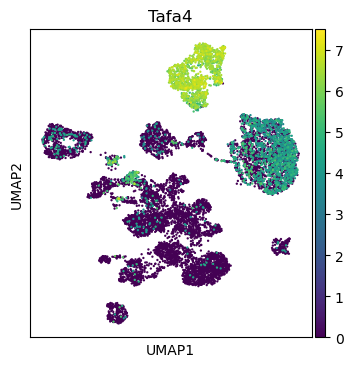

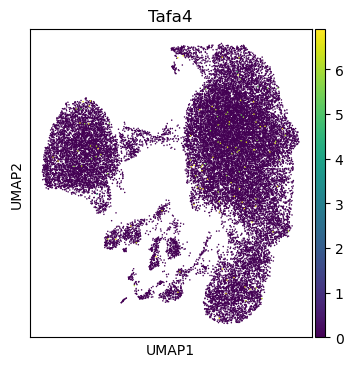

In [14]:
for ad in adata_list:
    sc.pl.umap(ad, color = 'Tafa4')

# Final modifcations

## add genes

In [15]:
genes_to_add = [
    "Siglecf", "Cd200r3", "Itga2", "Gata3", "Thy1", "Il5", "S100a8", "S100a9", "Gfap"
]

# Step 1: Create new rows for genes not already in panel
new_genes_df = pd.DataFrame({'Gene': genes_to_add})
new_genes_df = new_genes_df[~new_genes_df['Gene'].isin(panel['Gene'])]

# Step 2: Reindex to match panel's structure
new_genes_df = new_genes_df.reindex(columns=panel.columns)

# Step 3: Set boolean columns to False for new genes
new_genes_df[boolean_columns] = False

# Step 4: Optional — set neuron_DEGs explicitly (if present)
if "neuron_DEGs" in new_genes_df.columns:
    new_genes_df["neuron_DEGs"] = False

# Step 5: Append
panel = pd.concat([panel, new_genes_df], ignore_index=True)
panel

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,Notes
0,Pdcd1,ENSMUSG00000026285,8.0,True,True,False,False,False,False,False,False,NaN
1,Adra2a,ENSMUSG00000033717,8.0,True,False,False,False,False,False,False,False,NaN
2,Il1r1,ENSMUSG00000026072,8.0,True,False,False,False,False,False,False,False,NaN
3,Il6st,ENSMUSG00000021756,8.0,True,False,False,False,False,False,False,False,NaN
4,Tnfrsf1a,ENSMUSG00000030341,8.0,True,False,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
476,Gata3,NaN,NaN,False,False,False,False,False,False,False,False,NaN
477,Il5,NaN,NaN,False,False,False,False,False,False,False,False,NaN
478,S100a8,NaN,NaN,False,False,False,False,False,False,False,False,NaN
479,S100a9,NaN,NaN,False,False,False,False,False,False,False,False,NaN


## Remove genes

In [16]:
genes_to_remove = [
    "Tigit", "Il17a", "Prf1", "Cdc20", "mt-Nd6", "Gja5"

]

panel = panel[~panel['Gene'].isin(genes_to_remove)]
panel

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,Notes
0,Pdcd1,ENSMUSG00000026285,8.0,True,True,False,False,False,False,False,False,NaN
1,Adra2a,ENSMUSG00000033717,8.0,True,False,False,False,False,False,False,False,NaN
2,Il1r1,ENSMUSG00000026072,8.0,True,False,False,False,False,False,False,False,NaN
3,Il6st,ENSMUSG00000021756,8.0,True,False,False,False,False,False,False,False,NaN
4,Tnfrsf1a,ENSMUSG00000030341,8.0,True,False,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
476,Gata3,NaN,NaN,False,False,False,False,False,False,False,False,NaN
477,Il5,NaN,NaN,False,False,False,False,False,False,False,False,NaN
478,S100a8,NaN,NaN,False,False,False,False,False,False,False,False,NaN
479,S100a9,NaN,NaN,False,False,False,False,False,False,False,False,NaN


# Calculate gene detection rate

In [17]:
# Check how many duplicates there are
dup_counts = panel["Gene"].value_counts()
duplicates = dup_counts[dup_counts > 1]
print("Duplicate genes after renaming:\n", duplicates)

Duplicate genes after renaming:
 Series([], Name: count, dtype: int64)


In [18]:
# Step 1: Build detection matrix across adata_list
gene_detection_matrix = pd.DataFrame(index=panel["Gene"])

for i, ad in enumerate(adata_list):
    col_name = f"adata_{i}"
    detected_genes = gene_detection_matrix.index.intersection(ad.var_names)
    detection_percent = (ad[:, detected_genes].X > 0).sum(axis=0) / ad.n_obs * 100
    gene_detection_matrix.loc[detected_genes, col_name] = (
        detection_percent.A1 if hasattr(detection_percent, "A1") else detection_percent
    )

# Step 2: Rename columns to match desired names
gene_detection_matrix = gene_detection_matrix.rename(columns={
    "adata_0": "neuron_detection_rate",
    "adata_1": "glia_detection_rate"
})

# Step 3: Calculate combined detection rate
gene_detection_matrix["combined_detection_rate"] = gene_detection_matrix[
    ["neuron_detection_rate", "glia_detection_rate"]
].mean(axis=1, skipna=True)

# Step 4: Merge into panel
panel = panel.merge(
    gene_detection_matrix,
    how="left",
    left_on="Gene",
    right_index=True
)

In [19]:
panel

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,Notes,neuron_detection_rate,glia_detection_rate,combined_detection_rate
0,Pdcd1,ENSMUSG00000026285,8.0,True,True,False,False,False,False,False,False,NaN,NaN,0.000000,0.000000
1,Adra2a,ENSMUSG00000033717,8.0,True,False,False,False,False,False,False,False,NaN,4.809395,0.646754,2.728075
2,Il1r1,ENSMUSG00000026072,8.0,True,False,False,False,False,False,False,False,NaN,6.207475,1.462057,3.834766
3,Il6st,ENSMUSG00000021756,8.0,True,False,False,False,False,False,False,False,NaN,80.510765,17.544685,49.027725
4,Tnfrsf1a,ENSMUSG00000030341,8.0,True,False,False,False,False,False,False,False,NaN,4.045111,11.574945,7.810028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Gata3,NaN,NaN,False,False,False,False,False,False,False,False,NaN,8.220710,0.019599,4.120154
477,Il5,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.195731,0.015679,0.105705
478,S100a8,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.382142,0.160709,0.271425
479,S100a9,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.139808,0.160709,0.150258


### Rename genes to mm10 convention after calculating gene detection rate

In [20]:
# Gene renaming map
#gene_updates = {
#    "Fam19a1": "Tafa1",
#    "Mrgprc11": "Mrgprx1",
#    "Il6r": "Il6ra",
#    "Cyr61": "Ccn1",
#    "2810417H13Rik": "Pclaf",
#    "Fam19a5": "Tafa5",
#    "Abcb1": "Abcb1a"
#}

# Apply renaming
#panel["Gene"] = panel["Gene"].replace(gene_updates)

In [21]:
filename = Path(output_dir) / "2025-07-11_drg-draft-panel.csv"
panel.to_csv(filename, index=False)

# Finishing touches

Iterative modifications and backup genes:

In [22]:
panel

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,Notes,neuron_detection_rate,glia_detection_rate,combined_detection_rate
0,Pdcd1,ENSMUSG00000026285,8.0,True,True,False,False,False,False,False,False,NaN,NaN,0.000000,0.000000
1,Adra2a,ENSMUSG00000033717,8.0,True,False,False,False,False,False,False,False,NaN,4.809395,0.646754,2.728075
2,Il1r1,ENSMUSG00000026072,8.0,True,False,False,False,False,False,False,False,NaN,6.207475,1.462057,3.834766
3,Il6st,ENSMUSG00000021756,8.0,True,False,False,False,False,False,False,False,NaN,80.510765,17.544685,49.027725
4,Tnfrsf1a,ENSMUSG00000030341,8.0,True,False,False,False,False,False,False,False,NaN,4.045111,11.574945,7.810028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Gata3,NaN,NaN,False,False,False,False,False,False,False,False,NaN,8.220710,0.019599,4.120154
477,Il5,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.195731,0.015679,0.105705
478,S100a8,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.382142,0.160709,0.271425
479,S100a9,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.139808,0.160709,0.150258


In [23]:
genes_to_remove = [
    "Calm1", "Rps15a", "Rps20", "Stmn1", "Dad1", "Hsp90b1", "Xist", "N6amt2", "Tmem261",
    "Aimp1", "Bola1", "Bpgm", "Ccdc25", "Coq7", "Csrp1", "Ctnnb1", "Dad1", "Emp3",
    "Fam216a", "Fkbp2", "Gm1673", "Hmgn3", "Idi1", "Lysmd2", "Lysmd4", "Me1", "Ostf1",
    "Pbdc1", "Pet100", "Pou4f1", "Psmg3", "Psph", "Serinc5", "Serpina3n", "Ubald2", "Id3",
    "Glul", "Tecr", "Tjp1", "Pmvk", "Krcc1", "Dbh", "Mcm3", "Rbfox3", "Chat", "Mrps6",
    "Chrna1", "Gria2", "Tgfbi", "Nr2f2", "mt-Nd6" #"Adrb3", "Gabra2", "Il17rd", "Gja5", 

    # Genes removed 7/8

    ## add_on
    "Il10", "Gfap", "Dlg5", "Gabrb3", "Grin1", "Hey1", "Tubb3", "Mpz", "S100b", "Chrna1", "Chrna7", "Chrna10", "Tie1", "Cdh5", "Apoe", "Cd47", "Cd200", "Dmd", "Fabp7", "Junb",
    "Snap25", "Col1a1",

    ## unsupervised neuron fraction --> problematic
    "Adprh", "Gpm6b", "Hsf2", "Insig1", "Kdm6b", "Mrps28", "Nudt2", "Pdcd4", "Pttg1", "Rbm15", "Rpgrip1", "Sf3b5", "Snrpd1", "Tax1bp3", "Timm9", "Zbtb8os", "Zswim7", "Pim1",

    # unsupervised persist on non neuronal fraction (not problematic but redundancy can be trimmed)
    #"Adamts5", "Cald1", "Dhh", "Ednrb", "Fmo1", "Grrp1", "Rhoc", "Sec11c", "Srsf4", "Ube216"
]

# secondary list --> might want to re-run with an additional five genes from below moved up to genes_to_remove
backup_genes_to_remove = [
    "Tie1",
    "Pecam1",
    "Junb",
    "Egr1",
    "Fosb",
    "Cyr61",
    "Nr4a1",
    "Ly6g",
    "P2ry6",
    "Cd80",
    "Cd86",
    #"Gja5",
    #"Il17rd",
    "Cd200",
    #"Gabra2",
    #"Adrb3",
]

In [24]:
genes_to_remove = [
    "Calm1", "Rps15a", "Rps20", "Stmn1", "Dad1", "Hsp90b1", "Xist", "N6amt2", "Tmem261",
    "Aimp1", "Bola1", "Bpgm", "Ccdc25", "Coq7", "Csrp1", "Ctnnb1", "Dad1", "Emp3",
    "Fam216a", "Fkbp2", "Gm1673", "Hmgn3", "Idi1", "Lysmd2", "Lysmd4", "Me1", "Ostf1",
    "Pbdc1", "Pet100", "Pou4f1", "Psmg3", "Psph", "Serinc5", "Serpina3n", "Ubald2", "Id3",
    "Glul", "Tecr", "Tjp1", "Pmvk", "Krcc1", "Dbh", "Mcm3", "Rbfox3", "Chat", "Mrps6",
    "Chrna1", "Gria2", "Tgfbi", "Nr2f2", "mt-Nd6" #"Adrb3", "Gabra2", "Il17rd", "Gja5", 

    # Genes removed 7/8

    ## from add_on
    "Il10", "Dlg5", "Gabrb3", "Grin1", "Hey1", "Tubb3", "Mpz", "S100b", "Chrna1", "Chrna7", "Chrna10", "Tie1", "Cdh5", "Apoe", "Cd47", "Cd200", "Dmd", "Junb", # "Fabp7", "Gfap",
    "Snap25", "Col1a1",

    ## unsupervised neuron fraction --> problematic
    "Adprh", "Gpm6b", "Hsf2", "Insig1", "Kdm6b", "Mrps28", "Nudt2", "Pdcd4", "Pttg1", "Rbm15", "Rpgrip1", "Sf3b5", "Snrpd1", "Tax1bp3", "Timm9", "Zbtb8os", "Zswim7", "Pim1",

    # unsupervised persist on non neuronal fraction (not problematic but redundancy can be trimmed)
    #"Adamts5", "Cald1", "Dhh", "Ednrb", "Fmo1", "Grrp1", "Rhoc", "Sec11c", "Srsf4", "Ube216"

    # Genes removed 7/11
    "Tigit", "Il17a", "Prf1", "mt-Nd6", "Cdc20"
]

In [25]:
# Remove genes
panel_filtered = panel[~panel["Gene"].isin(genes_to_remove)]

# Drop duplicate genes
panel_filtered = panel_filtered.drop_duplicates(subset="Gene", keep="first")

# Count TRUE values in each column
true_counts = panel_filtered.select_dtypes(include=bool).sum()

# Print result
print(true_counts)

zhen_list               114
spectral_panel           48
neurons_supervised       49
neurons_unsupervised     17
glia_supervised          47
glia_unsupervised        27
other                   143
neuron_DEGs              24
dtype: int64


In [26]:
panel_filtered

,Gene,Ensembl ID,Probesets,zhen_list,spectral_panel,neurons_supervised,neurons_unsupervised,glia_supervised,glia_unsupervised,other,neuron_DEGs,Notes,neuron_detection_rate,glia_detection_rate,combined_detection_rate
0,Pdcd1,ENSMUSG00000026285,8.0,True,True,False,False,False,False,False,False,NaN,NaN,0.000000,0.000000
1,Adra2a,ENSMUSG00000033717,8.0,True,False,False,False,False,False,False,False,NaN,4.809395,0.646754,2.728075
2,Il1r1,ENSMUSG00000026072,8.0,True,False,False,False,False,False,False,False,NaN,6.207475,1.462057,3.834766
3,Il6st,ENSMUSG00000021756,8.0,True,False,False,False,False,False,False,False,NaN,80.510765,17.544685,49.027725
4,Tnfrsf1a,ENSMUSG00000030341,8.0,True,False,False,False,False,False,False,False,NaN,4.045111,11.574945,7.810028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Gata3,NaN,NaN,False,False,False,False,False,False,False,False,NaN,8.220710,0.019599,4.120154
477,Il5,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.195731,0.015679,0.105705
478,S100a8,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.382142,0.160709,0.271425
479,S100a9,NaN,NaN,False,False,False,False,False,False,False,False,NaN,0.139808,0.160709,0.150258


In [27]:
filename = Path(output_dir) / "2025-07-11_drg-draft-panel-filtered.csv"
#panel_filtered.to_csv(filename, index=False)

# Session info

In [28]:
import os
print('active IDE: sc-sq-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-sq-gpu
active conda environment: sc-spatial


In [29]:
#sc.pl.umap(bdata, color = ['Col3a1', 'Apoe', 'Fabp7', 'Mbp', 'Mpz'], frameon = False, ncols = 5)